In [2]:
import sys

project_path = '/content/drive/MyDrive/credit_score_project'

if project_path not in sys.path:
    sys.path.append(project_path)

In [3]:
import kagglehub
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import joblib
import my_module.custom_transformers as cst
from datetime import datetime
sklearn.set_config(transform_output = 'pandas')
pd.set_option("display.max_columns",None)

In [4]:
csc_dataset_raw =pd.read_csv('/content/drive/MyDrive/credit_score_project/datasets_cleaned/csc_cleaned.csv',index_col='Unnamed: 0')
csc_df = csc_dataset_raw.copy()

In [ ]:
csc_df

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,Credit_Score,spent_behaviour,spent_value
0,3392,1.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,80.415295,312.494089,Good,High,Small
1,3392,2.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,6.5,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,118.280222,284.629162,Good,Low,Large
2,3392,3.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,81.699521,331.209863,Good,Low,Medium
3,3392,4.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,199.458074,223.451310,Good,Low,Small
4,3392,5.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",6.0,6.5,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,41.420153,341.489231,Good,High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,37932,4.0,25.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"auto loan,student loan",23.0,7.0,11.50,3.0,Good,502.38,34.663572,378.0,No,35.104023,60.971333,479.866228,Poor,High,Large
99996,37932,5.0,25.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"auto loan,student loan",18.0,7.0,11.50,3.0,Good,502.38,40.565631,379.0,No,35.104023,54.185950,496.651610,Poor,High,Medium
99997,37932,6.0,25.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"auto loan,student loan",27.0,6.0,11.50,3.0,Good,502.38,41.255522,380.0,No,35.104023,24.028477,516.809083,Poor,High,Large
99998,37932,7.0,25.0,Mechanic,39628.99,3359.415833,4.0,6.0,7.0,2.0,"auto loan,student loan",20.0,6.0,11.50,3.0,Good,502.38,33.638208,381.0,No,35.104023,251.672582,319.164979,Standard,Low,Large


In [5]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GroupKFold

gkf = GroupKFold(n_splits=3)

X = csc_df.drop(columns=['Credit_Score'])
y = csc_df['Credit_Score'].map({'Poor':2,'Standard':1,'Good':0})
groups = csc_df['Customer_ID']

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

train_customers = set(X_train['Customer_ID'])
test_customers = set(X_test['Customer_ID'])

train_groups = X_train['Customer_ID']
test_groups = X_test['Customer_ID']
print("No of Common customers:", train_customers.intersection(test_customers))

print(y_train.value_counts()/y_train.shape[0])
print(y_test.value_counts()/y_test.shape[0])

No of Common customers: set()
Credit_Score
1    0.531875
2    0.289812
0    0.178313
Name: count, dtype: float64
Credit_Score
1    0.53120
2    0.29065
0    0.17815
Name: count, dtype: float64


In [ ]:
X_train

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,spent_behaviour,spent_value
0,3392,1.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,80.415295,312.494089,High,Small
1,3392,2.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,6.5,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,118.280222,284.629162,Low,Large
2,3392,3.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,81.699521,331.209863,Low,Medium
3,3392,4.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,199.458074,223.451310,Low,Small
4,3392,5.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",6.0,6.5,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,41.420153,341.489231,High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,14124,4.0,18.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,NaN,14.0,0.0,5.10,1.0,Good,1079.48,30.625298,340.0,No,34.975457,31.193919,520.662207,High,Large
99964,14124,5.0,18.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,NaN,14.0,0.0,5.10,1.0,Good,1079.48,23.140640,341.0,No,34.975457,450.646093,151.210033,Low,Small
99965,14124,6.0,19.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,NaN,14.0,0.0,5.10,1.0,Good,1079.48,35.549456,342.0,No,34.975457,187.355969,394.500158,Low,Large
99966,14124,7.0,19.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,NaN,14.0,0.0,5.10,1.0,Good,1079.48,35.123480,343.0,No,34.975457,240.873798,350.982329,Low,Medium


In [6]:
csc_preprocess = joblib.load('/content/drive/MyDrive/credit_score_project/preprocessing/csc_preprocess_v1.joblib')

from sklearn.pipeline import check_is_fitted
try:
  check_is_fitted(csc_preprocess)
except:
  print("not fitted")


not fitted


In [ ]:
X_train

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance,spent_behaviour,spent_value
0,3392,1.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,7.0,11.27,4.0,Good,809.98,26.822620,265.0,No,49.574949,80.415295,312.494089,High,Small
1,3392,2.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,6.5,11.27,4.0,Good,809.98,31.944960,266.0,No,49.574949,118.280222,284.629162,Low,Large
2,3392,3.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",3.0,7.0,11.27,4.0,Good,809.98,28.609352,267.0,No,49.574949,81.699521,331.209863,Low,Medium
3,3392,4.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",5.0,4.0,6.27,4.0,Good,809.98,31.377862,268.0,No,49.574949,199.458074,223.451310,Low,Small
4,3392,5.0,23.0,Scientist,19114.12,1824.843333,3.0,4.0,3.0,4.0,"auto loan,credit-builder loan,personal loan,ho...",6.0,6.5,11.27,4.0,Good,809.98,24.797347,269.0,No,49.574949,41.420153,341.489231,High,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,14124,4.0,18.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,NaN,14.0,0.0,5.10,1.0,Good,1079.48,30.625298,340.0,No,34.975457,31.193919,520.662207,High,Large
99964,14124,5.0,18.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,NaN,14.0,0.0,5.10,1.0,Good,1079.48,23.140640,341.0,No,34.975457,450.646093,151.210033,Low,Small
99965,14124,6.0,19.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,NaN,14.0,0.0,5.10,1.0,Good,1079.48,35.549456,342.0,No,34.975457,187.355969,394.500158,Low,Large
99966,14124,7.0,19.0,Lawyer,42903.79,3468.315833,0.0,4.0,6.0,1.0,NaN,14.0,0.0,5.10,1.0,Good,1079.48,35.123480,343.0,No,34.975457,240.873798,350.982329,Low,Medium


In [7]:
X_train_preprocessed = csc_preprocess.fit_transform(X_train)
X_test_preprocessed = csc_preprocess.transform(X_test)
X_train_preprocessed.head()

Index(['Type_of_Loan'], dtype='object')
Index(['Type_of_Loan'], dtype='object')


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) [' ', ',', '-', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'y'] will be ignored
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


,categorical__debt consolidation loan,categorical__student loan,categorical__auto loan,categorical__credit-builder loan,categorical__mortgage loan,categorical__home equity loan,categorical__personal loan,categorical__payday loan,categorical__not specified,categorical__Occupation_Accountant,categorical__Occupation_Architect,categorical__Occupation_Developer,categorical__Occupation_Doctor,categorical__Occupation_Engineer,categorical__Occupation_Entrepreneur,categorical__Occupation_Journalist,categorical__Occupation_Lawyer,categorical__Occupation_Manager,categorical__Occupation_Mechanic,categorical__Occupation_Media_Manager,categorical__Occupation_Musician,categorical__Occupation_Scientist,categorical__Occupation_Teacher,categorical__Occupation_Writer,categorical__Credit_Mix,categorical__spent_value,categorical__Payment_of_Min_Amount,categorical__spent_behaviour,categorical__Month,numerical__Monthly_Balance,numerical__Amount_invested_monthly,numerical__Total_EMI_per_month,numerical__Outstanding_Debt,numerical__Num_of_Loan,numerical__Monthly_Inhand_Salary,numerical__Annual_Income,numerical__Age,numerical__Num_Bank_Accounts,numerical__Num_Credit_Card,numerical__Interest_Rate,numerical__Delay_from_due_date,numerical__Num_of_Delayed_Payment,numerical__Changed_Credit_Limit,numerical__Num_Credit_Inquiries,numerical__Credit_Utilization_Ratio,numerical__Credit_History_Age
0,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,-0.243568,-0.552297,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.216656,-0.995225,0.120783,-0.452059,-1.067523,0.437370
1,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0,0.0,2.0,-0.419438,-0.243785,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.216656,-1.074653,0.120783,-0.452059,-0.067479,0.447405
2,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,3.0,-0.134013,-0.539654,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.216656,-0.995225,0.120783,-0.452059,-0.718696,0.457441
3,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,4.0,-0.874832,0.175573,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.081414,-1.471798,-0.633341,-0.452059,-0.178195,0.467476
4,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,1.0,5.0,-0.076439,-1.078940,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.013794,-1.074653,0.120783,-0.452059,-1.462921,0.477511


Now after the prepocessing pipeline is completed we can go ahead and use the
pipleline for different models. First step is to make a base LR classifier and
discuss all the matric that we will be using for evaluation

In [ ]:
from sklearn.linear_model import LogisticRegression
csc_base_lr = LogisticRegression()
csc_base_lr.fit(X_train_preprocessed,y_train)
y_pred = csc_base_lr.predict(X_test_preprocessed)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    log_loss,
    brier_score_loss,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    classification_report
)

from sklearn.calibration import calibration_curve
from sklearn.inspection import permutation_importance

def save_results_to_excel(
    metrics_df,
    dataset_name,
    model_name,
    params,
    comments=None,
    file_path="model_results.xlsx"
):

    # -----------------------------
    # Convert metrics to single row
    # -----------------------------
    metrics_row = metrics_df.T.reset_index(drop=True)

    # -----------------------------
    # Metadata
    # -----------------------------
    meta = pd.DataFrame([{
        "dataset_name": dataset_name,
        "model_name": model_name,
        "params": str(params),
        "comments": comments,
        "timestamp": datetime.now()
    }])

    # -----------------------------
    # Combine everything
    # -----------------------------
    final_row = pd.concat([meta, metrics_row], axis=1)

    # -----------------------------
    # Save / append to Excel
    # -----------------------------
    if os.path.exists(file_path):
        existing = pd.read_excel(file_path)
        final_row = pd.concat([existing, final_row], ignore_index=True)

    final_row.to_excel(file_path, index=False)

    print(f"Results saved to {file_path}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    log_loss,
    auc
)

from sklearn.inspection import permutation_importance
from sklearn.preprocessing import label_binarize
from sklearn.calibration import calibration_curve
from sklearn.metrics import precision_recall_curve


def evaluate_model(
    model,
    X_train,
    y_train,
    X_test,
    y_test,
    feature_names=None,
    n_repeats=20
):

    results = {}

    # -----------------------------
    # Class distribution
    # -----------------------------
    results["class_weight_train"] = f"{y_train.value_counts(normalize=True)}"
    results["class_weight_test"] = f"{y_test.value_counts(normalize=True)}"

    # -----------------------------
    # Predictions
    # -----------------------------
    train_proba = model.predict_proba(X_train)
    test_proba = model.predict_proba(X_test)

    train_pred = np.argmax(train_proba, axis=1)
    test_pred = np.argmax(test_proba, axis=1)

    classes = np.unique(y_train)
    n_classes = len(classes)

    # -----------------------------
    # ROC AUC (Multiclass)
    # -----------------------------
    auc_train = roc_auc_score(
        y_train,
        train_proba,
        multi_class="ovr",
        average="weighted"
    )

    auc_test = roc_auc_score(
        y_test,
        test_proba,
        multi_class="ovr",
        average="weighted"
    )

    results["ROC_AUC_train"] = auc_train
    results["ROC_AUC_test"] = auc_test
    results["Gini"] = 2 * auc_test - 1

    # -----------------------------
    # Probability Metrics
    # -----------------------------
    results["LogLoss"] = log_loss(y_test, test_proba)

    # Multiclass Brier
    y_test_bin = label_binarize(y_test, classes=classes)
    brier = np.mean((y_test_bin - test_proba) ** 2)
    results["BrierScore"] = brier

    # -----------------------------
    # Classification Metrics
    # -----------------------------
    results["Accuracy"] = accuracy_score(y_test, test_pred)
    results["Precision"] = precision_score(y_test, test_pred, average="weighted")
    results["Recall"] = recall_score(y_test, test_pred, average="weighted")
    results["F1"] = f1_score(y_test, test_pred, average="weighted")

    results["classification_report"] = f"{classification_report(y_test, test_pred)}"

    # -----------------------------
    # Generalization
    # -----------------------------
    train_error = 1 - accuracy_score(y_train, train_pred)
    test_error = 1 - accuracy_score(y_test, test_pred)

    results["Train_Error"] = train_error
    results["Test_Error"] = test_error
    results["Overfit_Gap_AUC"] = auc_train - auc_test

    results_df = pd.DataFrame(results, index=["Model_Evaluation"]).T

    # =============================
    # Feature Importance
    # =============================
    perm = permutation_importance(
        model,
        X_test,
        y_test,
        n_repeats=n_repeats,
        scoring="roc_auc_ovr",
        random_state=42
    )

    if feature_names is None:
        feature_names = X_test.columns

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std
    }).sort_values("importance_mean", ascending=False)

    # =============================
    # ROC Curves (One vs Rest)
    # =============================
    y_test_bin = label_binarize(y_test, classes=classes)

    fig, axes = plt.subplots(2,2, figsize=(12,10))

    for i in range(n_classes):

        fpr, tpr, _ = roc_curve(y_test_bin[:,i], test_proba[:,i])
        roc_auc = auc(fpr,tpr)

        axes[0,0].plot(fpr, tpr, label=f"Class {classes[i]} AUC={roc_auc:.3f}")

    axes[0,0].plot([0,1],[0,1],'--')
    axes[0,0].set_title("ROC Curve (One-vs-Rest)")
    axes[0,0].legend()

    # -----------------------------
    # PR Curve (per class)
    # -----------------------------
    for i in range(n_classes):

        precision, recall, _ = precision_recall_curve(
            y_test_bin[:,i],
            test_proba[:,i]
        )

        axes[0,1].plot(recall, precision, label=f"Class {classes[i]}")

    axes[0,1].set_title("Precision-Recall Curve")
    axes[0,1].legend()

    # -----------------------------
    # Confusion Matrix
    # -----------------------------
    cm = confusion_matrix(y_test, test_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[1,0])
    axes[1,0].set_title("Confusion Matrix")

    # -----------------------------
    # Calibration Curve (per class)
    # -----------------------------
    for i in range(n_classes):

        prob_true, prob_pred = calibration_curve(
            y_test_bin[:,i],
            test_proba[:,i],
            n_bins=10
        )

        axes[1,1].plot(prob_pred, prob_true, marker="o", label=f"class {classes[i]}")

    axes[1,1].plot([0,1],[0,1],'--')
    axes[1,1].set_title("Calibration Curve")
    axes[1,1].legend()

    plt.tight_layout()
    plt.show()

    # -----------------------------
    # Feature Importance Plot
    # -----------------------------
    plt.figure(figsize=(8,6))
    plt.barh(importance_df["feature"], importance_df["importance_mean"])
    plt.gca().invert_yaxis()
    plt.title("Permutation Feature Importance")
    plt.xlabel("Decrease in ROC-AUC")
    plt.show()

    return results_df, importance_df

# Does the model rank risk well?
# Does the model identify defaulters?
# Are probabilities reliable?
# Does model generalize?
# What drives predictions?

In [ ]:
metrics, feature_importance= evaluate_model(
    model=csc_base_lr,
    X_train=X_train_preprocessed,
    y_train=y_train,
    X_test=X_test_preprocessed,
    y_test=y_test
)

KeyboardInterrupt: 

In [ ]:
metrics

,Model_Evaluation
class_weight_train,Credit_Score\n1 0.531875\n2 0.289812\n0 ...
class_weight_test,Credit_Score\n1 0.53120\n2 0.29065\n0 ...
ROC_AUC_train,0.797073
ROC_AUC_test,0.79513
Gini,0.590259
LogLoss,0.758352
BrierScore,0.150771
Accuracy,0.65275
Precision,0.653658
Recall,0.65275


In [ ]:
# save_results_to_excel(
#     metrics_df=metrics,
#     dataset_name="CSC",
#     model_name="Base_Logistic_Regression",
#     params=csc_base_lr.get_params(),
#     comments="baseline model",
#     file_path = '/content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx'
# )

In [ ]:
df_train = pd.concat([X_train_preprocessed,y_train],axis=1)
df_train

,categorical__debt consolidation loan,categorical__student loan,categorical__auto loan,categorical__credit-builder loan,categorical__mortgage loan,categorical__home equity loan,categorical__personal loan,categorical__payday loan,categorical__not specified,categorical__Occupation_Accountant,categorical__Occupation_Architect,categorical__Occupation_Developer,categorical__Occupation_Doctor,categorical__Occupation_Engineer,categorical__Occupation_Entrepreneur,categorical__Occupation_Journalist,categorical__Occupation_Lawyer,categorical__Occupation_Manager,categorical__Occupation_Mechanic,categorical__Occupation_Media_Manager,categorical__Occupation_Musician,categorical__Occupation_Scientist,categorical__Occupation_Teacher,categorical__Occupation_Writer,categorical__Credit_Mix,categorical__spent_value,categorical__Payment_of_Min_Amount,categorical__spent_behaviour,categorical__Month,numerical__Monthly_Balance,numerical__Amount_invested_monthly,numerical__Total_EMI_per_month,numerical__Outstanding_Debt,numerical__Num_of_Loan,numerical__Monthly_Inhand_Salary,numerical__Annual_Income,numerical__Age,numerical__Num_Bank_Accounts,numerical__Num_Credit_Card,numerical__Interest_Rate,numerical__Delay_from_due_date,numerical__Num_of_Delayed_Payment,numerical__Changed_Credit_Limit,numerical__Num_Credit_Inquiries,numerical__Credit_Utilization_Ratio,numerical__Credit_History_Age,Credit_Score
0,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,1.0,1.0,-0.243568,-0.552297,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.216656,-0.995225,0.120783,-0.452059,-1.067523,0.437370,0
1,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,2.0,0.0,0.0,2.0,-0.419438,-0.243785,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.216656,-1.074653,0.120783,-0.452059,-0.067479,0.447405,0
2,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,3.0,-0.134013,-0.539654,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.216656,-0.995225,0.120783,-0.452059,-0.718696,0.457441,0
3,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,0.0,0.0,4.0,-0.874832,0.175573,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.081414,-1.471798,-0.633341,-0.452059,-0.178195,0.467476,0
4,0,0,1,1,0,1,1,0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,1.0,5.0,-0.076439,-1.078940,-0.090156,-0.137261,0.429848,-0.671434,-0.859122,-0.955915,-0.907982,-0.726059,-1.315432,-1.013794,-1.074653,0.120783,-0.452059,-1.462921,0.477511,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99963,0,0,0,0,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,1.0,4.0,0.718551,-1.301771,-0.263636,0.129488,-0.981891,0.128300,0.160497,-1.421037,-2.064703,-0.726059,-0.972258,-0.472829,-2.107228,-0.809806,-1.224236,-0.325119,1.190020,1
99964,0,0,0,0,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,5.0,-1.608640,0.831751,-0.263636,0.129488,-0.981891,0.128300,0.160497,-1.421037,-2.064703,-0.726059,-0.972258,-0.472829,-2.107228,-0.809806,-1.224236,-1.786363,1.200056,0
99965,0,0,0,0,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,0.0,6.0,0.195455,0.125269,-0.263636,0.129488,-0.981891,0.128300,0.160497,-1.328013,-2.064703,-0.726059,-0.972258,-0.472829,-2.107228,-0.809806,-1.224236,0.636233,1.210091,0
99966,0,0,0,0,0,0,0,0,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,0.0,7.0,-0.024783,0.327288,-0.263636,0.129488,-0.981891,0.128300,0.160497,-1.328013,-2.064703,-0.726059,-0.972258,-0.472829,-2.107228,-0.809806,-1.224236,0.553

In [ ]:
df_train.columns
num_cols = ['numerical__Monthly_Balance',
       'numerical__Amount_invested_monthly', 'numerical__Total_EMI_per_month',
       'numerical__Outstanding_Debt', 'numerical__Num_of_Loan',
       'numerical__Monthly_Inhand_Salary', 'numerical__Annual_Income',
       'numerical__Age', 'numerical__Num_Bank_Accounts',
       'numerical__Num_Credit_Card', 'numerical__Interest_Rate',
       'numerical__Delay_from_due_date', 'numerical__Num_of_Delayed_Payment',
       'numerical__Changed_Credit_Limit', 'numerical__Num_Credit_Inquiries',
       'numerical__Credit_Utilization_Ratio', 'numerical__Credit_History_Age']
cat_cols = ['categorical__debt consolidation loan', 'categorical__student loan',
       'categorical__auto loan', 'categorical__credit-builder loan',
       'categorical__mortgage loan', 'categorical__home equity loan',
       'categorical__personal loan', 'categorical__payday loan',
       'categorical__not specified', 'categorical__Occupation_Accountant',
       'categorical__Occupation_Architect',
       'categorical__Occupation_Developer', 'categorical__Occupation_Doctor',
       'categorical__Occupation_Engineer',
       'categorical__Occupation_Entrepreneur',
       'categorical__Occupation_Journalist', 'categorical__Occupation_Lawyer',
       'categorical__Occupation_Manager', 'categorical__Occupation_Mechanic',
       'categorical__Occupation_Media_Manager',
       'categorical__Occupation_Musician', 'categorical__Occupation_Scientist',
       'categorical__Occupation_Teacher', 'categorical__Occupation_Writer',
       'categorical__Credit_Mix', 'categorical__spent_value',
       'categorical__Payment_of_Min_Amount', 'categorical__spent_behaviour',
       'categorical__Month']
target_col = ['Credit_Score']

NameError: name 'df_train' is not defined

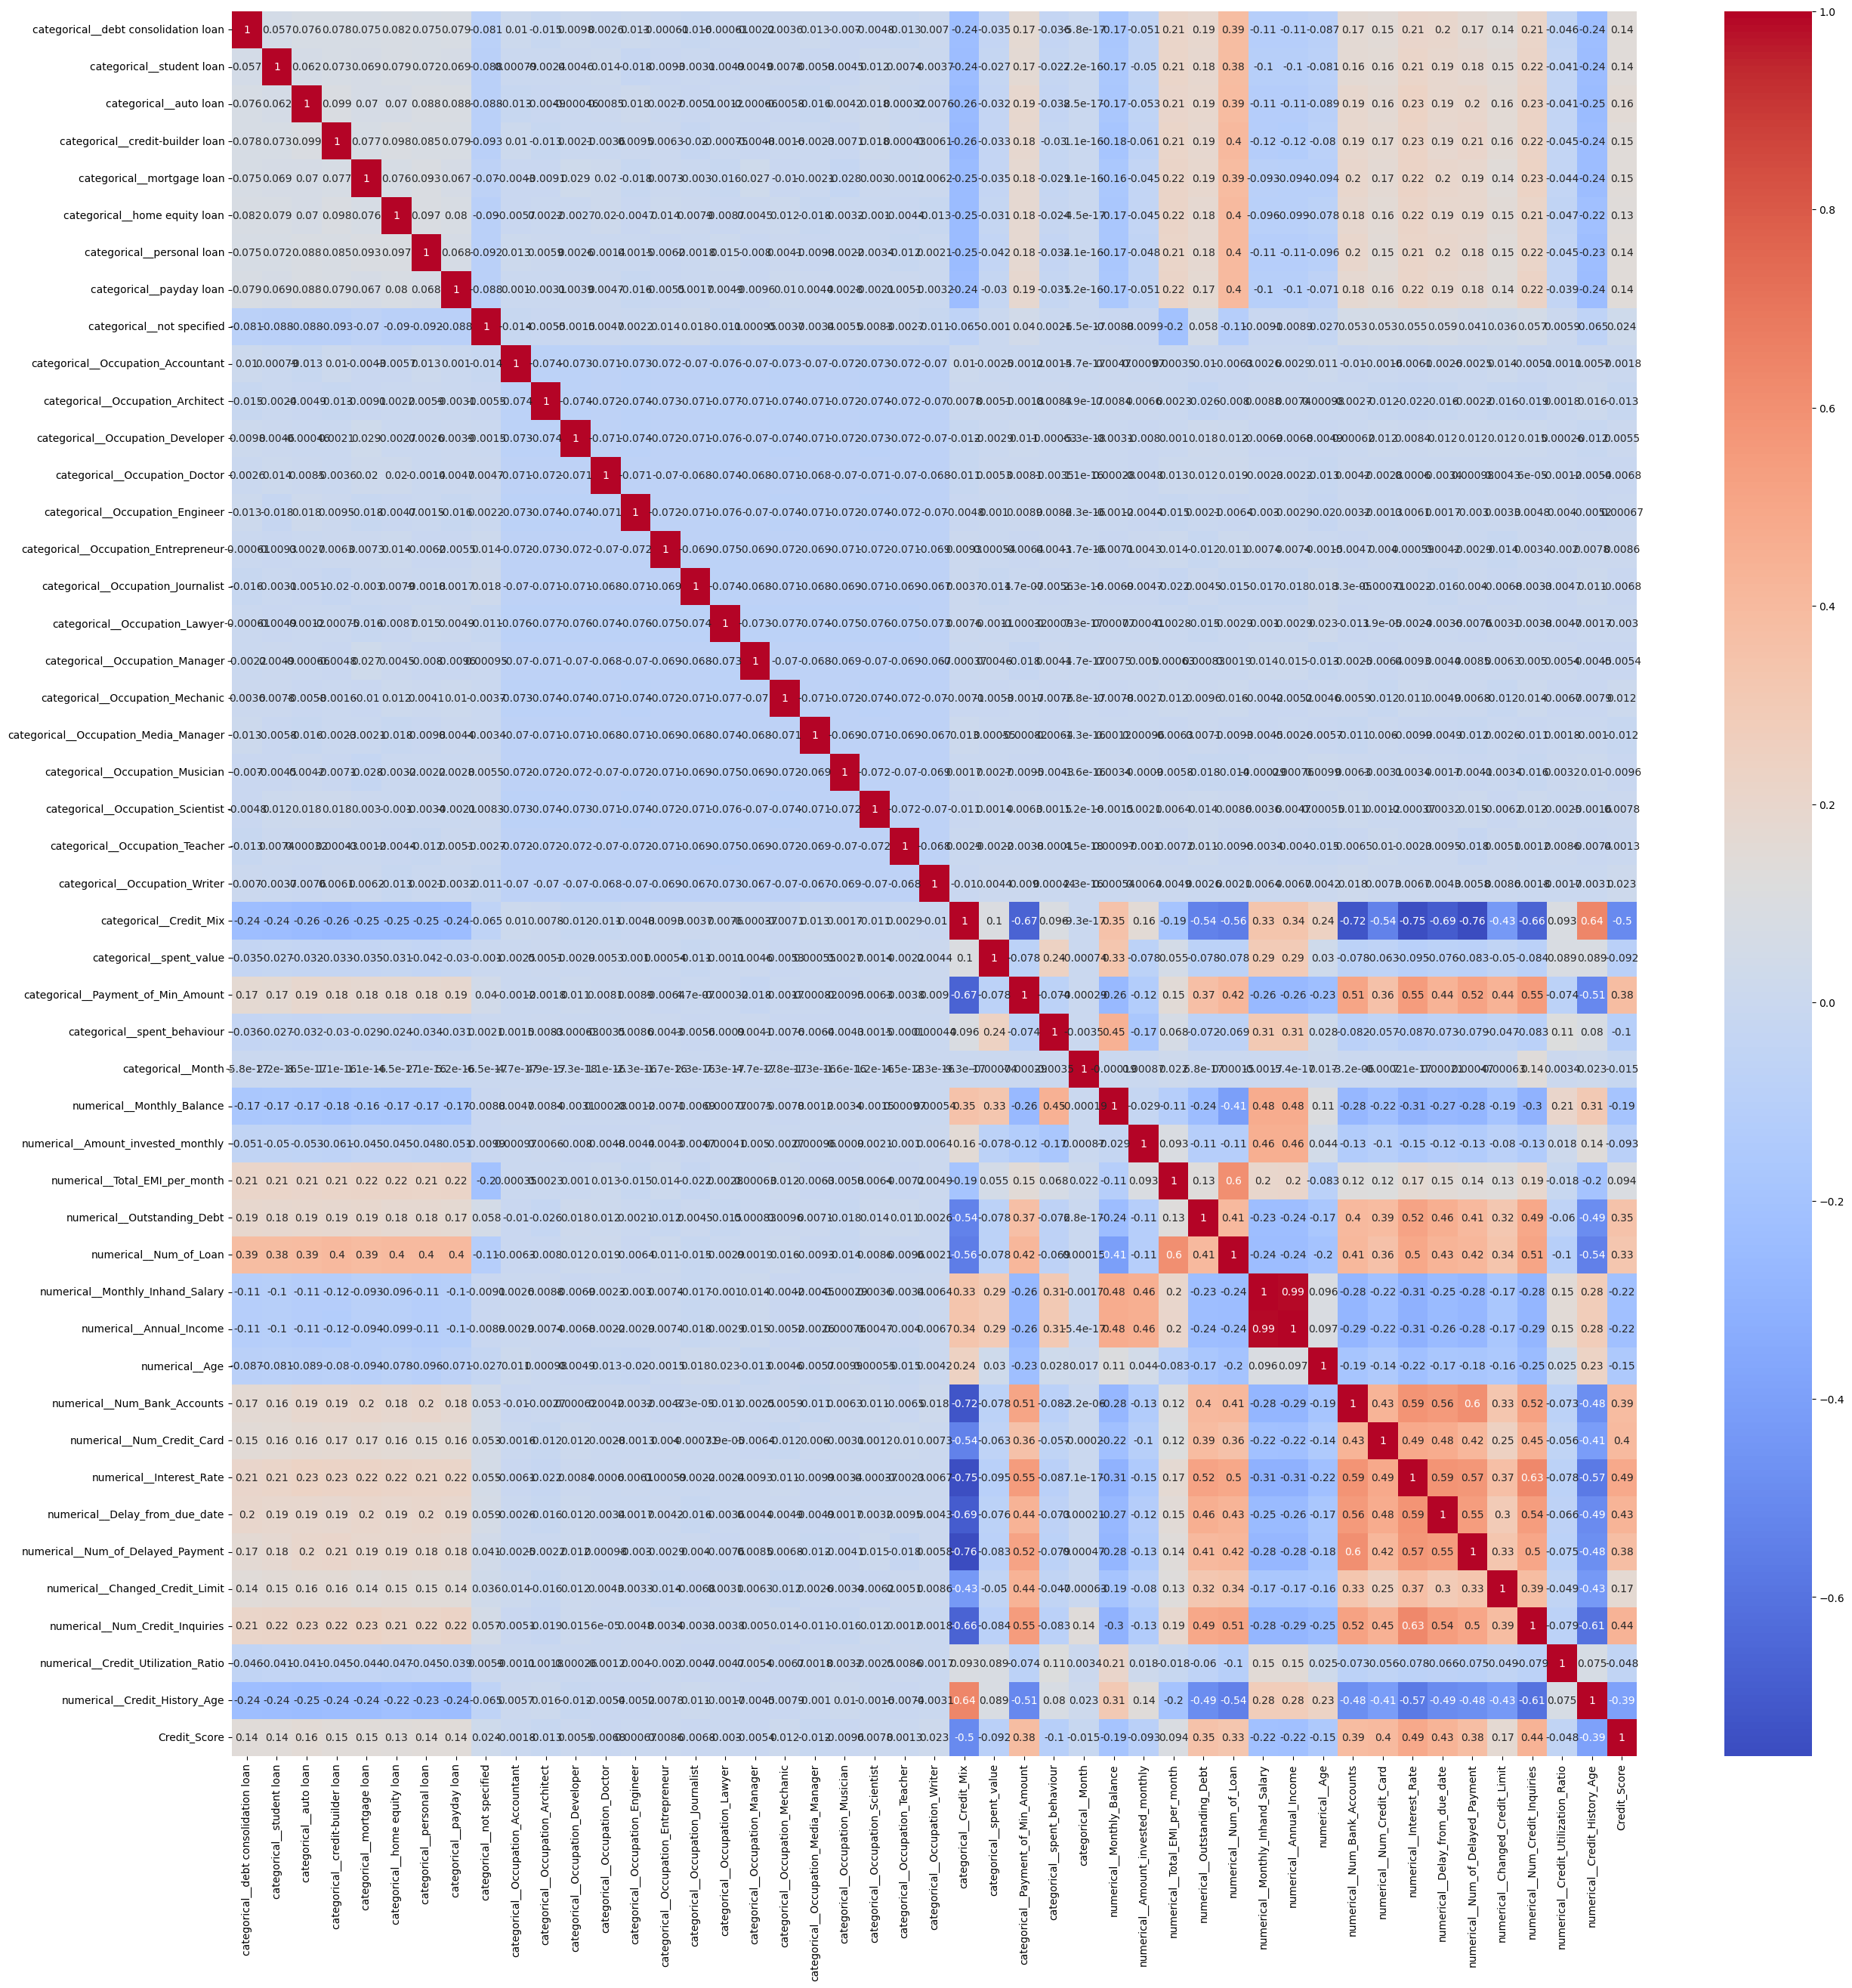

In [ ]:
corr_matrix = df_train.corr()
plt.figure(figsize=(30,30))
sns.heatmap(corr_matrix,annot=True,cmap = 'coolwarm')
plt.show()

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_train[num_cols]
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

vif_data.sort_values(by="VIF", ascending=False)

,Feature,VIF
6,numerical__Annual_Income,67.253429
5,numerical__Monthly_Inhand_Salary,67.126786
4,numerical__Num_of_Loan,2.953299
10,numerical__Interest_Rate,2.400952
14,numerical__Num_Credit_Inquiries,2.198898
16,numerical__Credit_History_Age,2.090771
2,numerical__Total_EMI_per_month,2.030255
8,numerical__Num_Bank_Accounts,1.990726
11,numerical__Delay_from_due_date,1.953185
12,numerical__Num_of_Delayed_Payment,1.924696


In [ ]:
import pandas as pd
from scipy.stats import f_oneway

results = []

for col in num_cols:

  groups = [
          group[col].dropna().values
          for _, group in df_train[num_cols+target_col].groupby('Credit_Score')
        ]

  if any(len(g) < 2 for g in groups):
            F_stat, p_value = None, None
  else:
            F_stat, p_value = f_oneway(*groups)

  results.append({
            "feature": col,
            "F_statistic": F_stat,
            "p_value": p_value,
            "Flag": p_value < 0.05
        })

anova_results = pd.DataFrame(results).sort_values("p_value")
anova_results

,feature,F_statistic,p_value,Flag
0,numerical__Monthly_Balance,1567.650635,0.000000e+00,True
3,numerical__Outstanding_Debt,5926.720360,0.000000e+00,True
5,numerical__Monthly_Inhand_Salary,1960.331256,0.000000e+00,True
4,numerical__Num_of_Loan,4980.670930,0.000000e+00,True
6,numerical__Annual_Income,2037.378969,0.000000e+00,True
7,numerical__Age,995.012273,0.000000e+00,True
9,numerical__Num_Credit_Card,7680.249724,0.000000e+00,True
8,numerical__Num_Bank_Accounts,7491.524384,0.000000e+00,True
12,numerical__Num_of_Delayed_Payment,7187.887607,0.000000e+00,True
13,numerical__Changed_Credit_Limit,2109.635595,0.000000e+00,True


In [ ]:
from scipy.stats import chi2_contingency
results = []
for col in cat_cols:
    contingency_table = pd.crosstab(df_train[col], df_train[target_col[0]])

    chi, p, dof, expected = chi2_contingency(contingency_table)
    results.append({
        "feature":col,
        "chi":chi ,
        "p_value":p,
        "Flag": p < 0.05,
        "dof":dof,
        "expected":expected
    })
chi_results = pd.DataFrame(results)
chi_results

,feature,chi,p_value,Flag,dof,expected
0,categorical__debt consolidation loan,1634.460939,0.000000e+00,True,2,"[[9825.732, 29308.44, 15969.828], [4439.268, 1..."
1,categorical__student loan,1674.138849,0.000000e+00,True,2,"[[9802.908, 29240.36, 15932.732], [4462.092, 1..."
2,categorical__auto loan,1952.305770,0.000000e+00,True,2,"[[9887.0715, 29491.405, 16069.5235], [4377.928..."
3,categorical__credit-builder loan,1714.316137,0.000000e+00,True,2,"[[9802.908, 29240.36, 15932.732], [4462.092, 1..."
4,categorical__mortgage loan,1720.887574,0.000000e+00,True,2,"[[9784.3635, 29185.045, 15902.5915], [4480.636..."
5,categorical__home equity loan,1439.650873,0.000000e+00,True,2,"[[9770.0985, 29142.495, 15879.4065], [4494.901..."
6,categorical__personal loan,1607.616876,0.000000e+00,True,2,"[[9837.144, 29342.48, 15988.376], [4427.856, 1..."
7,categorical__payday loan,1587.457715,0.000000e+00,True,2,"[[9703.053, 28942.51, 15770.437], [4561.947, 1..."
8,categorical__not specified,87.505831,9.962085e-20,True,2,"[[8112.5055, 24198.185, 13185.3095], [6152.494..."
9,categorical__Occupation_Accountant,13.883261,9.666920e-04,True,2,"[[13297.833, 39665.11, 21613.057], [967.167, 2..."


In [ ]:
chi_columns = list (chi_results[chi_results['Flag']==False].feature)
for col in chi_columns:
  print(df_train[col].value_counts())

categorical__Occupation_Developer
0.0    74512
1.0     5488
Name: count, dtype: int64
categorical__Occupation_Doctor
0.0    74856
1.0     5144
Name: count, dtype: int64
categorical__Occupation_Engineer
0.0    74504
1.0     5496
Name: count, dtype: int64
categorical__Occupation_Journalist
0.0    74896
1.0     5104
Name: count, dtype: int64
categorical__Occupation_Manager
0.0    74976
1.0     5024
Name: count, dtype: int64


The features with higher correlation and VIF needs to be removed. There is no action requried in case of categorical columns.

Monthly inhand salary - remove (imputation was done in preprocessing)
Credit_mix - relation with many columns but it is also good with target variable. So we can use trial and error for the decision.

In [9]:
X_train_FS = X_train_preprocessed.drop(columns=['numerical__Monthly_Inhand_Salary'])
X_test_FS = X_test_preprocessed.drop(columns=['numerical__Monthly_Inhand_Salary'])

In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


base_models = {
    "Logistic Regression": LogisticRegression(),

    # "SVM": SVC(kernel='linear',probability=True),

    # "KNN": KNeighborsClassifier(),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "XGBoost": XGBClassifier()
}

In [ ]:
all_results = []
feature_importance_df = pd.DataFrame()
all_results_df = pd.DataFrame()

for name, model in base_models.items():

    print(f"Training {name}")

    model.fit(X_train_FS, y_train)

    metrics, feature_importance = evaluate_model(
        model=model,
        X_train=X_train_FS,
        y_train=y_train,
        X_test=X_test_FS,
        y_test=y_test
)

    save_results_to_excel(
        metrics_df=metrics,
        dataset_name="Aus_Credit",
        model_name=f"Base_{name}",
        params=model.get_params(),
        comments="baseline model with Feature Selection",
        file_path = '/content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx'
)


    metrics = metrics.rename(columns={"Model_Evaluation":name})

    all_results_df = pd.concat([all_results_df,metrics],axis=1)

    renamed = {}
    for col in feature_importance.columns:
      renamed[col] = f"{name}_{col}"

    feature_importance = feature_importance.rename(columns=renamed)

    feature_importance_df = pd.concat([feature_importance_df,feature_importance],axis=1)


Training Logistic Regression


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KeyboardInterrupt: 

In [ ]:
KNN = KNeighborsClassifier()

KNN.fit(X_train_FS, y_train)

KNeighborsClassifier()

In [ ]:

Knn_metrics, knn_feature_importance = evaluate_model(
        model=KNN,
        X_train=X_train_FS,
        y_train=y_train,
        X_test=X_test_FS,
        y_test=y_test
)

KeyboardInterrupt: 

In [ ]:
SVM = SVC(kernel='linear',probability=True)
SVM_metrics, SVM_feature_importance = evaluate_model(
        model=SVM,
        X_train=X_train_FS,
        y_train=y_train,
        X_test=X_test_FS,
        y_test=y_test
)

NameError: name 'SVC' is not defined

In [ ]:
Knn_metrics

,KNN
class_weight_train,Credit_Score\n1 0.531875\n2 0.289812\n0 ...
class_weight_test,Credit_Score\n1 0.53120\n2 0.29065\n0 ...
ROC_AUC_train,0.945674
ROC_AUC_test,0.842677
Gini,0.685354
LogLoss,0.656807
BrierScore,0.133315
Accuracy,0.69705
Precision,0.696551
Recall,0.69705


In [ ]:
SVM_metrics

,SVM
class_weight_train,Credit_Score\n1 0.531875\n2 0.289812\n0 ...
class_weight_test,Credit_Score\n1 0.53120\n2 0.29065\n0 ...
ROC_AUC_train,0.945674
ROC_AUC_test,0.842677
Gini,0.685354
LogLoss,0.656807
BrierScore,0.133315
Accuracy,0.69705
Precision,0.696551
Recall,0.69705


In [ ]:
Knn_metrics = Knn_metrics.rename(columns={"Model_Evaluation":"KNN"})
SVM_metrics = SVM_metrics.rename(columns={"Model_Evaluation":"SVM"})
all_results_df = pd.concat([all_results_df,Knn_metrics,SVM_metrics],axis=1)

In [ ]:
renamed = {}
for col in SVM_feature_importance.columns:
  renamed[col] = f"{name}_{col}"

  SVM_feature_importance = SVM_feature_importance.rename(columns=renamed)

  feature_importance_df = pd.concat([feature_importance_df,SVM_feature_importance],axis=1)


In [ ]:
all_results_df

,Logistic Regression,Decision Tree,Random Forest,XGBoost,KNN,SVM
class_weight_train,Credit_Score\n1 0.531875\n2 0.289812\n0 ...,Credit_Score\n1 0.531875\n2 0.289812\n0 ...,Credit_Score\n1 0.531875\n2 0.289812\n0 ...,Credit_Score\n1 0.531875\n2 0.289812\n0 ...,Credit_Score\n1 0.531875\n2 0.289812\n0 ...,Credit_Score\n1 0.531875\n2 0.289812\n0 ...
class_weight_test,Credit_Score\n1 0.53120\n2 0.29065\n0 ...,Credit_Score\n1 0.53120\n2 0.29065\n0 ...,Credit_Score\n1 0.53120\n2 0.29065\n0 ...,Credit_Score\n1 0.53120\n2 0.29065\n0 ...,Credit_Score\n1 0.53120\n2 0.29065\n0 ...,Credit_Score\n1 0.53120\n2 0.29065\n0 ...
ROC_AUC_train,0.796991,1.0,1.0,0.945674,0.945674,0.945674
ROC_AUC_test,0.795142,0.671803,0.841784,0.842677,0.842677,0.842677
Gini,0.590284,0.343606,0.683568,0.685354,0.685354,0.685354
LogLoss,0.757218,13.992146,0.664826,0.656807,0.656807,0.656807
BrierScore,0.150532,0.2588,0.132555,0.133315,0.133315,0.133315
Accuracy,0.6536,0.6118,0.69775,0.69705,0.69705,0.69705
Precision,0.654072,0.610993,0.698435,0.696551,0.696551,0.696551
Recall,0.6536,0.6118,0.69775,0.69705,0.69705,0.69705


In [ ]:
# all_results_df.to_excel("/content/drive/MyDrive/credit_score_project/evaluation/gmsc_base_models.xlsx")
# feature_importance_df.to_excel("/content/drive/MyDrive/credit_score_project/evaluation/gmsc_base_models_FIMP.xlsx")

# Optuna

In [10]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 10.3 MB/s eta 0:00:00


In [11]:
import optuna
import numpy as np

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

def get_model(trial, model_name):

  if model_name == "logistic":

    solver = trial.suggest_categorical(
        "solver", ["saga", "liblinear", "lbfgs", "newton-cg"]
    )

    C = trial.suggest_float("C", 1e-2, 1e2, log=True)

    class_weight = trial.suggest_categorical(
        "class_weight", ["balanced", None]
    )

    if solver == "saga":

        penalty = "elasticnet"

        l1_ratio = trial.suggest_float("l1_ratio", 0.0, 1.0)

    elif solver == "liblinear":

        penalty = trial.suggest_categorical("penalty", ["l1", "l2"])
        l1_ratio = None

    elif solver in ["lbfgs", "newton-cg"]:

        penalty = "l2"
        l1_ratio = None

    model = LogisticRegression(
            solver=solver,
            penalty=penalty,
            C=C,
            l1_ratio=l1_ratio,
            class_weight=class_weight,
            max_iter=1000
        )

  elif model_name == "svm":

    kernel = trial.suggest_categorical("kernel", ["linear", "rbf"])

    # Common parameter
    C = trial.suggest_float("C", 1e-3, 1e3, log=True)

    if kernel == "rbf":

        gamma = trial.suggest_float("gamma", 1e-4, 1, log=True)

    else:
        gamma = "scale"

    model = SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            probability=True
        )


  elif model_name == "knn":

        n_neighbors = trial.suggest_int("n_neighbors", 3, 50)
        leaf_size = trial.suggest_int("leaf_size", 5, 50)
        weights = trial.suggest_categorical("weights", ["uniform", "distance"])
        p = trial.suggest_categorical("p", [1, 2])


        model = KNeighborsClassifier(
                n_neighbors=n_neighbors,
                weights=weights,
                p=p,
                leaf_size = leaf_size
            )


  elif model_name == "decision_tree":

        max_depth = trial.suggest_int("max_depth", 3, 30)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        max_features = trial.suggest_categorical("max_features", [None, "sqrt", "log2"])
        criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

        model = DecisionTreeClassifier(
            max_depth=max_depth,
            min_samples_split=min_samples_split,
            min_samples_leaf=min_samples_leaf,
            max_features=max_features,
            criterion=criterion
        )


  elif model_name == "random_forest":

        n_estimators = trial.suggest_int("n_estimators", 50, 400)
        max_depth = trial.suggest_int("max_depth", 5, 25)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 1, 20)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20)
        max_features = trial.suggest_categorical("max_features", ["sqrt", "log2", None])
        bootstrap = trial.suggest_categorical("bootstrap", [True, False])
        class_weight = trial.suggest_categorical("class_weight", [None, "balanced"])

        model = RandomForestClassifier(
            n_estimators=n_estimators,
            max_depth=max_depth,
            min_samples_leaf=min_samples_leaf,
            min_samples_split=min_samples_split,
            max_features=max_features,
            bootstrap=bootstrap,
            class_weight=class_weight,
            n_jobs=-1
        )


  elif model_name == "xgboost":

    n_estimators = trial.suggest_int("n_estimators", 100, 500)

    learning_rate = trial.suggest_float("learning_rate", 0.01, 0.3, log=True)

    max_depth = trial.suggest_int("max_depth", 4, 12)

    min_child_weight = trial.suggest_int("min_child_weight", 1, 10)

    subsample = trial.suggest_float("subsample", 0.6, 1.0)

    colsample_bytree = trial.suggest_float("colsample_bytree", 0.6, 1.0)

    gamma = trial.suggest_float("gamma", 0.0, 5.0)

    reg_alpha = trial.suggest_float("reg_alpha", 1e-3, 10, log=True)

    reg_lambda = trial.suggest_float("reg_lambda", 1e-3, 10, log=True)

    scale_pos_weight = trial.suggest_categorical(
        "scale_pos_weight", [1, 2, 3, 5]
    )

    model = XGBClassifier(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        min_child_weight=min_child_weight,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,
        scale_pos_weight=scale_pos_weight,
        eval_metric="logloss",
        use_label_encoder=False,
        n_jobs=-1
    )

  else:
      raise ValueError("Invalid model name")

  return model

In [12]:
def objective(trial, model_name, X_train, y_train):

    model = get_model(trial, model_name)

    score = cross_val_score(
        model,
        X_train,
        y_train,
        groups=train_groups,
        cv=gkf,
        scoring="roc_auc_ovr",
        n_jobs=-1
    ).mean()

    return score

In [13]:
def tune_model(model_name, X_train, y_train, n_trials=30):

    study = optuna.create_study(direction="maximize")

    study.optimize(
        lambda trial: objective(trial, model_name, X_train, y_train),
        n_trials=n_trials
    )

    return study

In [14]:
import optuna
from optuna.visualization import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_contour,
    plot_slice
)


def plot_optuna_diagnostics(study, plots=None):
    """
    Plots key Optuna diagnostic graphs.

    Parameters:
    ----------
    study : optuna.study.Study
        Completed Optuna study

    plots : list (optional)
        List of plots to generate. Options:
        ["history", "importance", "parallel", "contour", "slice"]
        Default = all
    """

    if plots is None:
        plots = ["history", "importance", "parallel", "contour", "slice"]

    print("\n📊 Optuna Study Diagnostics\n")

    # 1. Optimization History
    if "history" in plots:
        print("▶ Optimization History")
        fig = plot_optimization_history(study)
        fig.show()

    # 2. Parameter Importance
    if "importance" in plots:
        print("▶ Parameter Importance")
        fig = plot_param_importances(study)
        fig.show()

    # 3. Parallel Coordinate Plot
    if "parallel" in plots:
        print("▶ Parallel Coordinate Plot")
        fig = plot_parallel_coordinate(study)
        fig.show()

    # 4. Contour Plot (interaction between params)
    if "contour" in plots:
        print("▶ Contour Plot")
        fig = plot_contour(study)
        fig.show()

    # 5. Slice Plot (individual param vs objective)
    if "slice" in plots:
        print("▶ Slice Plot")
        fig = plot_slice(study)
        fig.show()

In [ ]:
train_groups.isnull().sum()

np.int64(0)

In [ ]:
study = tune_model('decision_tree', X_train_FS, y_train, n_trials=100)

[I 2026-04-01 19:03:47,261] A new study created in memory with name: no-name-3b960bf0-cefe-4251-9bdb-4b1fc7d32fb4
[I 2026-04-01 19:03:51,319] Trial 0 finished with value: 0.7994279595412088 and parameters: {'max_depth': 23, 'min_samples_split': 7, 'min_samples_leaf': 20, 'max_features': 'sqrt', 'criterion': 'gini'}. Best is trial 0 with value: 0.7994279595412088.
[I 2026-04-01 19:03:52,780] Trial 1 finished with value: 0.7393816935126281 and parameters: {'max_depth': 29, 'min_samples_split': 13, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 0 with value: 0.7994279595412088.
[I 2026-04-01 19:03:54,300] Trial 2 finished with value: 0.7767745065856583 and parameters: {'max_depth': 30, 'min_samples_split': 11, 'min_samples_leaf': 12, 'max_features': 'sqrt', 'criterion': 'entropy'}. Best is trial 0 with value: 0.7994279595412088.
[W 2026-04-01 19:03:55,246] Trial 3 failed with parameters: {'max_depth': 11, 'min_samples_split': 8, 'min_samples_leaf': 2

KeyboardInterrupt: 

In [ ]:
print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

plot_optuna_diagnostics(study)

Best Score: 0.7033269123876335
Best Params: {'solver': 'saga', 'C': 0.4785700427016291, 'class_weight': 'balanced', 'l1_ratio': 0.2132837811605799}

📊 Optuna Study Diagnostics

▶ Optimization History


▶ Parameter Importance


[W 2026-03-30 10:32:52,676] Your study has only completed trials with missing parameters.


▶ Parallel Coordinate Plot


▶ Contour Plot


/tmp/ipykernel_9417/2675857356.py:52: UserWarning:

Contour plot will not be displayed because `l1_ratio` and `penalty` cannot co-exist in `trial.params`.

/tmp/ipykernel_9417/2675857356.py:52: UserWarning:

Contour plot will not be displayed because `penalty` and `l1_ratio` cannot co-exist in `trial.params`.



▶ Slice Plot


In [ ]:
dycvgvvdthdh
ftudhd
fjfgj'
yjfgjd
ftudftgjbfssbs
jgdjsj
jdd
gdud
jyrut

In [ ]:
models = [
    # "logistic",
    # "decision_tree",
     "random_forest"
    # "xgboost"
]

all_studies = {}

for model_name in models:

    print(f"\nTuning {model_name}...")

    study = tune_model(model_name, X_train_FS, y_train, n_trials=50)

    all_studies[model_name] = study

    print("Best Score:", study.best_value)
    print("Best Params:", study.best_params)
    plot_optuna_diagnostics(study)

[I 2026-04-02 13:12:20,012] A new study created in memory with name: no-name-a174da51-3d42-420d-b74b-1ef2cbfcade6



Tuning random_forest...


[I 2026-04-02 13:13:43,380] Trial 0 finished with value: 0.8425560480785452 and parameters: {'n_estimators': 172, 'max_depth': 8, 'min_samples_leaf': 9, 'min_samples_split': 9, 'max_features': 'log2', 'bootstrap': False, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.8425560480785452.
[I 2026-04-02 13:15:13,617] Trial 1 finished with value: 0.8572640376910132 and parameters: {'n_estimators': 218, 'max_depth': 22, 'min_samples_leaf': 4, 'min_samples_split': 15, 'max_features': 'log2', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.8572640376910132.
[I 2026-04-02 13:16:33,022] Trial 2 finished with value: 0.8574834608429196 and parameters: {'n_estimators': 181, 'max_depth': 17, 'min_samples_leaf': 3, 'min_samples_split': 6, 'max_features': 'sqrt', 'bootstrap': True, 'class_weight': 'balanced'}. Best is trial 2 with value: 0.8574834608429196.
[I 2026-04-02 13:19:06,160] Trial 3 finished with value: 0.8599352895698966 and parameters: {'n_estimator

In [1]:
all_studies = {}
all_studies['random_forest'].best_params

NameError: name 'all_studies' is not defined

In [ ]:
{'n_estimators': 242, 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 2, 'max_features': None, 'bootstrap': True, 'class_weight': None}

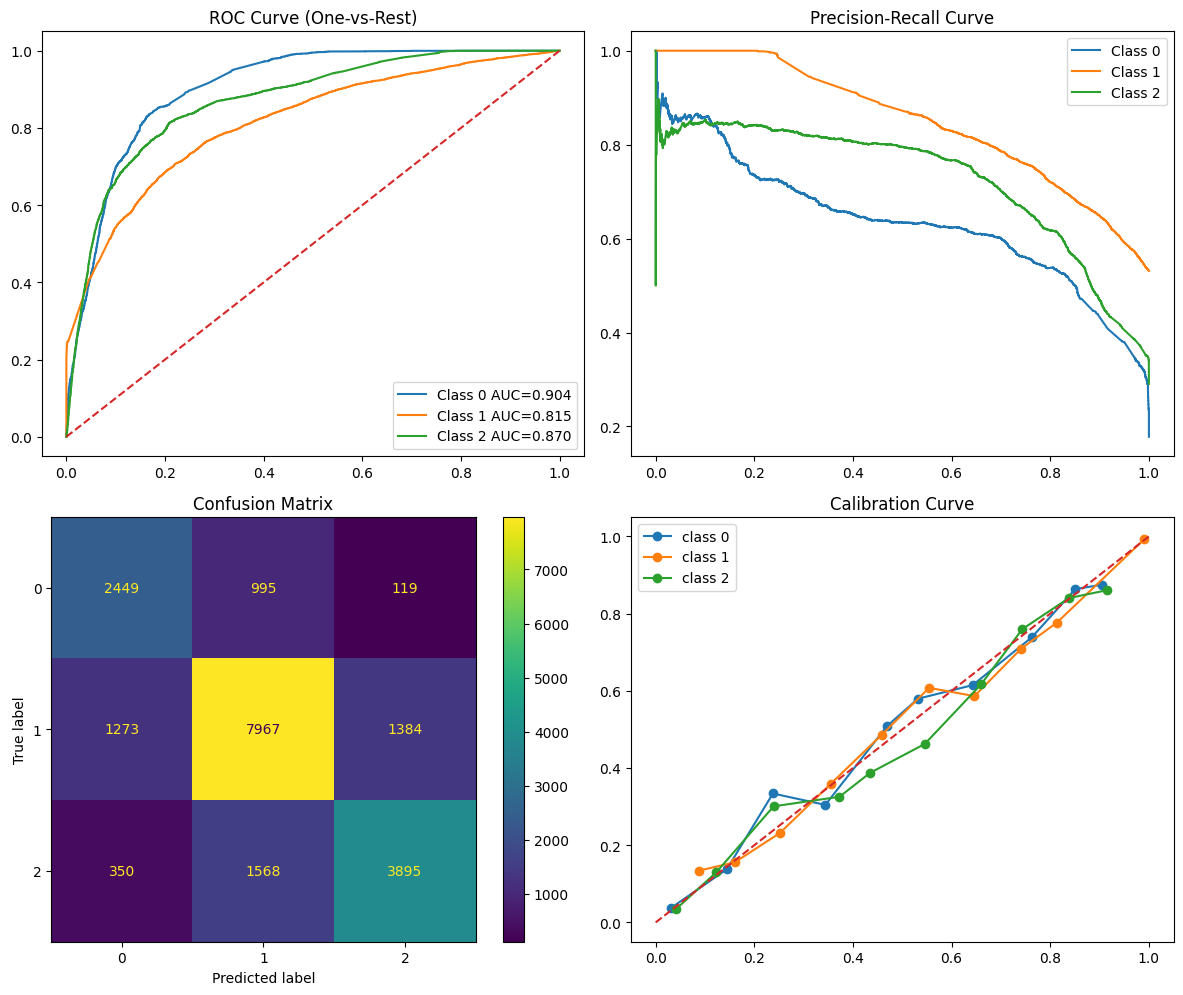

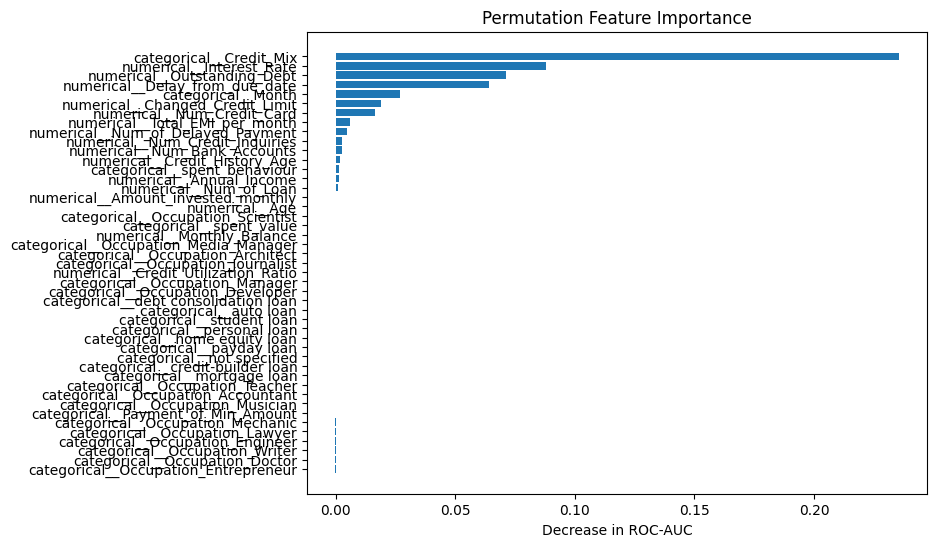

Results saved to /content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx


In [ ]:
models = [
    # "logistic",
    # "svm",
    # "knn",
    # "decision_tree"
     "random_forest"
    #  "xgboost"
]

for model_name in models:
  best_params = {'n_estimators': 242, 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 2, 'max_features': None, 'bootstrap': True, 'class_weight': None}
  trial = optuna.trial.FixedTrial(best_params)
  best_model = get_model(trial, model_name)

  best_model.fit(X_train_FS, y_train)

  metrics, feature_importance = evaluate_model(
          model=best_model,
          X_train=X_train_FS,
          y_train=y_train,
          X_test=X_test_FS,
          y_test=y_test
      )

  save_results_to_excel(
        metrics_df=metrics,
        dataset_name="CSC",
        model_name=f"HPT_{model_name}",
        params=best_model.get_params(),
        comments="Tunned model",
        file_path = '/content/drive/MyDrive/credit_score_project/evaluation/models_evaluation.xlsx'
)